<a href="https://colab.research.google.com/github/sig-gis/cwcb-landcover-mapping/blob/main/00_Intial_Explorations/LandCover_Segformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

OEM_DRIVE = "/content/drive/MyDrive/datasets/OpenEarthMap"   # source on Drive
OEM_LOCAL = "/content/OpenEarthMap"                           # local copy
os.makedirs(OEM_LOCAL, exist_ok=True)

In [ ]:
# import os, shutil
# from concurrent.futures import ThreadPoolExecutor
# from tqdm.auto import tqdm

# src_files = [os.path.join(r, f) for r, _, fs in os.walk(OEM_DRIVE) for f in fs]

# for d in {os.path.dirname(os.path.join(OEM_LOCAL, os.path.relpath(p, OEM_DRIVE)))
#           for p in src_files}:
#     os.makedirs(d, exist_ok=True)

# def copy_one(src):
#     dst = os.path.join(OEM_LOCAL, os.path.relpath(src, OEM_DRIVE))
#     if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
#         shutil.copyfile(src, dst)

# with ThreadPoolExecutor(max_workers=32) as ex:
#     list(tqdm(ex.map(copy_one, src_files), total=len(src_files), unit="file"))

In [ ]:
import os, glob

pairs, unpaired = [], []
for region in sorted(os.listdir(OEM_LOCAL)):
    img_dir = os.path.join(OEM_LOCAL, region, "images")
    lbl_dir = os.path.join(OEM_LOCAL, region, "labels")
    if not os.path.isdir(img_dir):
        continue
    for img in sorted(glob.glob(os.path.join(img_dir, "*.tif*"))):
        lbl = os.path.join(lbl_dir, os.path.basename(img))
        if os.path.isfile(lbl) and os.path.getsize(img) > 0 and os.path.getsize(lbl) > 0:
            pairs.append((os.path.splitext(os.path.basename(img))[0], img, lbl))
        else:
            unpaired.append(img)

print(f"{len(pairs)} usable image/label pairs; {len(unpaired)} images without a valid label")

2687 usable image/label pairs; 1151 images without a valid label


In [ ]:
# # OpenEarthMap US regions — check the "dropped" list and add any I missed
# US_CITIES = {
#     "austin", "chicago", "kitsap",   # Inria
#     "vegas", "atlanta",              # SpaceNet
# }

# def region(t): return t.rsplit("_", 1)[0]

# cities = sorted({region(t) for t, _, _ in pairs})
# pairs  = [p for p in pairs if region(p[0]) in US_CITIES]

# print(f"{len(pairs)} tiles across US cities: {sorted({region(p[0]) for p in pairs})}")
# print("dropped:", [c for c in cities if c not in US_CITIES])

In [ ]:
!pip -q install transformers rasterio

import os, random, numpy as np
import torch, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

In [ ]:
OEM_CLASSES = ["unknown", "bareland", "rangeland", "developed", "road",
               "tree", "water", "agriculture", "building"]          # label values 0..8
OEM_HEX     = ["#000000", "#800000", "#00FF24", "#949494", "#FFFFFF",
               "#226126", "#0045FF", "#4BB549", "#DE1F07"]

CHECKPOINT = "nvidia/mit-b4"
IMG_SIZE   = 512
BATCH      = 20
EPOCHS     = 2000
LR         = 6e-5
PATIENCE   = 6
device     = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
proc = SegformerImageProcessor(size={"height": IMG_SIZE, "width": IMG_SIZE})

class OEMTiles(Dataset):
    def __init__(self, items):
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        _, img_path, lbl_path = self.items[i]
        with rasterio.open(img_path) as s:
            img = np.moveaxis(s.read()[:3], 0, -1)   # (H, W, 3) RGB
        with rasterio.open(lbl_path) as s:
            lbl = s.read(1)                          # (H, W) values 0..8
        enc = proc(images=img, segmentation_maps=lbl, return_tensors="pt")
        return enc["pixel_values"][0], enc["labels"][0]

rng = random.Random(0)
items = pairs[:]; rng.shuffle(items)
n_val = max(1, int(0.15 * len(items)))
val_items, train_items = items[:n_val], items[n_val:]

train_dl = DataLoader(OEMTiles(train_items), BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(OEMTiles(val_items),   BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"{len(train_items)} train / {len(val_items)} val tiles")

2284 train / 403 val tiles


In [ ]:
id2label = {i: c for i, c in enumerate(OEM_CLASSES)}
model = SegformerForSemanticSegmentation.from_pretrained(
    CHECKPOINT,
    num_labels=len(OEM_CLASSES),
    id2label=id2label,
    label2id={c: i for i, c in id2label.items()},
    ignore_mismatched_sizes=True,
).to(device)

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/914 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b4
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.num_batches_tracked              

In [ ]:
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.PolynomialLR(opt, total_iters=EPOCHS * len(train_dl), power=1.0)

@torch.no_grad()
def val_scores():
    model.eval()
    n = len(OEM_CLASSES)
    conf = np.zeros((n, n), dtype=np.int64)
    for img, lbl in val_dl:
        logits = model(pixel_values=img.to(device)).logits
        logits = F.interpolate(logits, lbl.shape[-2:], mode="bilinear", align_corners=False)
        pred = logits.argmax(1).cpu().numpy().ravel()
        conf += np.bincount(n * lbl.numpy().ravel() + pred, minlength=n * n).reshape(n, n)
    inter = np.diag(conf)
    union = conf.sum(0) + conf.sum(1) - inter
    iou = inter / np.maximum(union, 1)
    return float(iou[union > 0].mean()), float(inter.sum() / conf.sum())

best_miou, wait = -1.0, 0
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for img, lbl in train_dl:
        loss = model(pixel_values=img.to(device), labels=lbl.to(device)).loss
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        running += loss.item()
    miou, acc = val_scores()
    tag = ""
    if miou > best_miou:
        best_miou, wait = miou, 0
        model.save_pretrained("/content/segformer_oem")
        tag = "  (saved)"
    else:
        wait += 1
    print(f"epoch {epoch + 1:2d}  train_loss {running / len(train_dl):.3f}  val_mIoU {miou:.3f}  val_acc {acc:.3f}{tag}")
    if wait >= PATIENCE:
        print(f"early stop — best val_mIoU {best_miou:.3f}, no gain in {PATIENCE} epochs")
        break

model = SegformerForSemanticSegmentation.from_pretrained("/content/segformer_oem").to(device)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch  1  train_loss 1.002  val_mIoU 0.592  val_acc 0.699  (saved)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch  2  train_loss 0.731  val_mIoU 0.619  val_acc 0.719  (saved)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 31  train_loss 0.373  val_mIoU 0.686  val_acc 0.775  (saved)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 32  train_loss 0.370  val_mIoU 0.687  val_acc 0.775  (saved)
epoch 33  train_loss 0.366  val_mIoU 0.685  val_acc 0.774
epoch 34  train_loss 0.361  val_mIoU 0.685  val_acc 0.772
epoch 35  train_loss 0.359  val_mIoU 0.686  val_acc 0.775
epoch 36  train_loss 0.355  val_mIoU 0.685  val_acc 0.776
epoch 37  train_loss 0.353  val_mIoU 0.682  val_acc 0.773
epoch 38  train_loss 0.350  val_mIoU 0.686  val_acc 0.774
early stop — best val_mIoU 0.687, no gain in 6 epochs


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

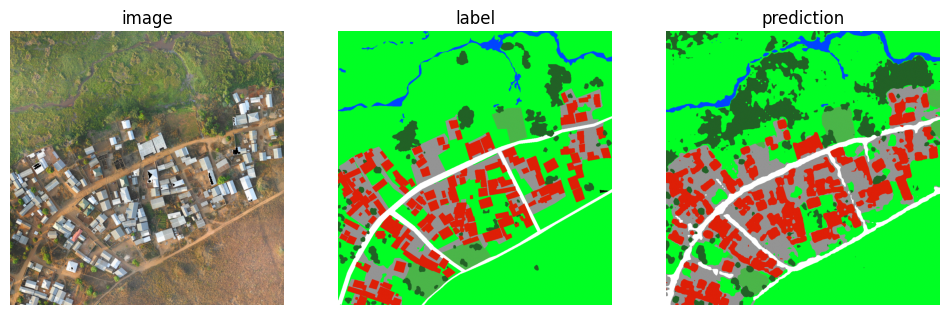

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(OEM_HEX)
_, img_path, lbl_path = val_items[50]
with rasterio.open(img_path) as s: rgb = np.moveaxis(s.read()[:3], 0, -1)
with rasterio.open(lbl_path) as s: lbl = s.read(1)

model.eval()
with torch.no_grad():
    px = proc(images=rgb, return_tensors="pt")["pixel_values"].to(device)
    logits = model(pixel_values=px).logits
    pred = F.interpolate(logits, rgb.shape[:2], mode="bilinear", align_corners=False).argmax(1)[0].cpu()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rgb);                              ax[0].set_title("image")
ax[1].imshow(lbl,  cmap=cmap, vmin=0, vmax=8);  ax[1].set_title("label")
ax[2].imshow(pred, cmap=cmap, vmin=0, vmax=8);  ax[2].set_title("prediction")
for a in ax: a.axis("off")
plt.show()

In [ ]:
import subprocess
from google.colab import userdata

tok = userdata.get("Vexcel_CO")
out = subprocess.run([
    "curl", "-sS", "-X", "POST",
    f"https://api.vexcelgroup.com/v2/ortho/extract?token={tok}",
    "-H", "accept: image/jpeg",
    "-H", "Content-Type: application/json",
    "-w", "\nHTTP %{http_code} | %{content_type} | %{size_download} bytes\n",
    "-o", "golden_co_tile.tif",
    "-d", '''{
  "layer": "urban",
  "wkt": "POLYGON((-105.20815459164398 39.745966248831074,-105.20816082784461 39.74803858046841,-105.21084544856902 39.74803373528506,-105.21083913194242 39.745961404001875,-105.20815459164398 39.745966248831074))",
  "srid": 4326,
  "bands": "rgb",
  "zoom": 19,
  "crop": "clip",
  "attribution": "true",
  "image-format": "tiff"
}''',
], capture_output=True, text=True)
print(out.stdout, out.stderr)


HTTP 200 | image/tiff | 542479 bytes
 


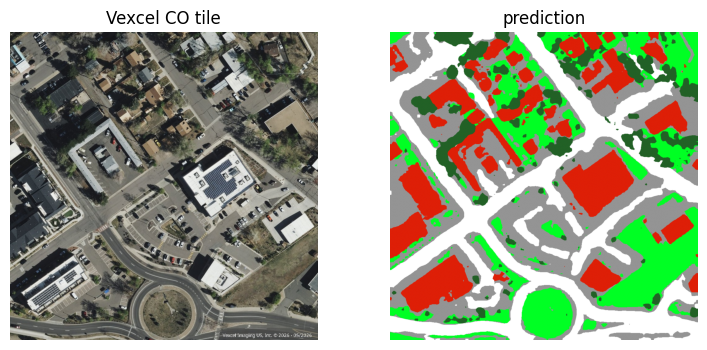

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(OEM_HEX)
with rasterio.open("golden_co_tile.tif") as s: rgb = np.moveaxis(s.read()[:3], 0, -1)

model.eval()
with torch.no_grad():
    px = proc(images=rgb, return_tensors="pt")["pixel_values"].to(device)
    logits = model(pixel_values=px).logits
    pred = F.interpolate(logits, rgb.shape[:2], mode="bilinear", align_corners=False).argmax(1)[0].cpu()

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(rgb);                              ax[0].set_title("Golden CO tile")
ax[1].imshow(pred, cmap=cmap, vmin=0, vmax=8);  ax[1].set_title("prediction")
for a in ax: a.axis("off")
plt.show()

In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(userdata.get("HF_TOKEN"))

HF_NAME = userdata.get("HF_NAME")
model.push_to_hub(f"{HF_NAME}/segformer-oem-b5")   # best weights + config
proc.push_to_hub(f"{HF_NAME}/segformer-oem-b5")    # preprocessing config

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eblhi3u/model.safetensors:  97%|#########6|  248MB /  256MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/MaxLeft/segformer-oem-b5/commit/078bcb62f420a042966566a8ed72f1456e87c0a8', commit_message='Upload processor', commit_description='', oid='078bcb62f420a042966566a8ed72f1456e87c0a8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/MaxLeft/segformer-oem-b5', endpoint='https://huggingface.co', repo_type='model', repo_id='MaxLeft/segformer-oem-b5'), pr_revision=None, pr_num=None)

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/256M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

   rangeland:  18.4%
   developed:  30.9%
        road:  25.0%
        tree:   7.8%
    building:  17.9%


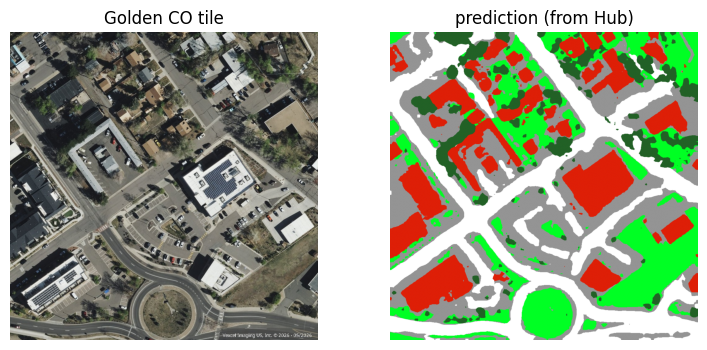

In [ ]:
from google.colab import userdata
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

repo = f"{userdata.get('HF_NAME')}/segformer-oem-b4"
hub_model = SegformerForSemanticSegmentation.from_pretrained(repo).to(device).eval()
hub_proc  = SegformerImageProcessor.from_pretrained(repo)

with rasterio.open("golden_co_tile.tif") as s:
    rgb = np.moveaxis(s.read()[:3], 0, -1)

with torch.no_grad():
    px = hub_proc(images=rgb, return_tensors="pt")["pixel_values"].to(device)
    logits = hub_model(pixel_values=px).logits
    pred = F.interpolate(logits, rgb.shape[:2], mode="bilinear", align_corners=False).argmax(1)[0].cpu().numpy()

for c, n in zip(*np.unique(pred, return_counts=True)):
    print(f"{OEM_CLASSES[c]:>12}: {100 * n / pred.size:5.1f}%")

cmap = ListedColormap(OEM_HEX)
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(rgb);                              ax[0].set_title("Golden CO tile")
ax[1].imshow(pred, cmap=cmap, vmin=0, vmax=8);  ax[1].set_title("prediction (from Hub)")
for a in ax: a.axis("off")
plt.show()